In [52]:
import pandas as pd
import matplotlib.pyplot as plt

In [53]:
# STEP 1 : Load the data from CSV files

df_catalog = pd.read_csv("/Users/hanane/Ironhack/beauty_project/sql_beauty_project/data/query-results/sephora share of each category in the catalog.csv")
df_segment = pd.read_csv("/Users/hanane/Ironhack/beauty_project/sql_beauty_project/data/query-results/sephora skincare vs everything else.csv")
df_price   = pd.read_csv("/Users/hanane/Ironhack/beauty_project/sql_beauty_project/data/query-results/sephora products average rating per price.csv")


In [54]:
PINK  = "#E0517F"
GREY  = "#D0D0D0"
BLACK = "#1A1A1A"

## Hypothesis 1 : Price range vs Average rating

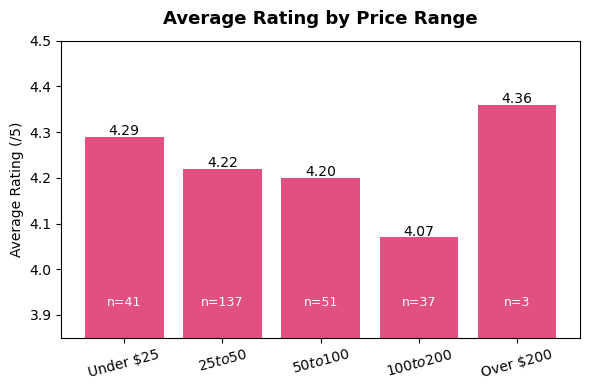

In [68]:
# ── Chart 3 : Average rating by price range ── 
plt.figure(figsize=(6, 4))
bars = plt.bar(df_price["price_range"], df_price["avg_rating"], color=PINK, width=0.80)
# Add rating + product count on each bar
for bar, rating, nb in zip(bars, df_price["avg_rating"], df_price["nb_products"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
             f"{rating:.2f}", ha="center", fontsize=10)
    plt.text(bar.get_x() + bar.get_width() / 2, 3.92,
             f"n={nb}", ha="center", fontsize=9, color="white")
 
plt.title("Average Rating by Price Range", fontsize=13, fontweight="bold", pad=12)
plt.ylabel("Average Rating (/5)")
plt.ylim(3.85, 4.5)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

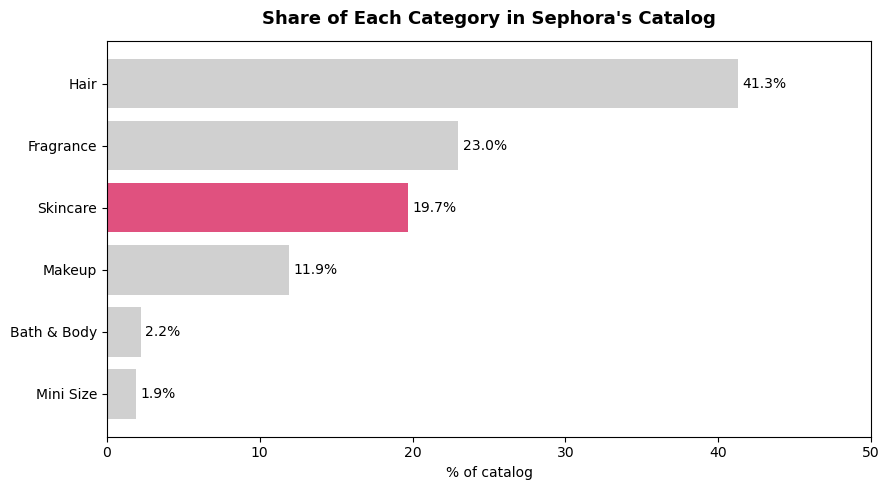

In [57]:
# ── Chart 1 : Share of each category ──
df_catalog = df_catalog.sort_values("pct_of_catalog", ascending=True)
 
# Skincare bar is pink, all others are grey
colors = [PINK if c == "Skincare" else GREY for c in df_catalog["category_name"]]
 
plt.figure(figsize=(9, 5))
bars = plt.barh(df_catalog["category_name"], df_catalog["pct_of_catalog"], color=colors)
 
# Add the % value at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height() / 2,
             f"{width}%", va="center", fontsize=10)
 
plt.title("Share of Each Category in Sephora's Catalog", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("% of catalog")
plt.xlim(0, 50)
plt.tight_layout()
plt.show()

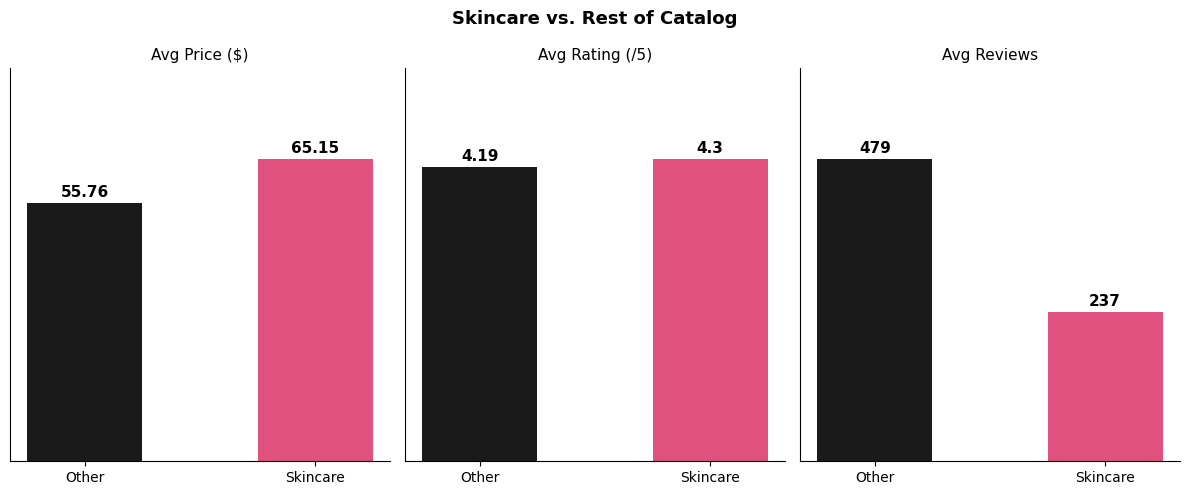

In [59]:
# ── Chart 2 : Skincare vs Other — 3 metrics ──
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle("Skincare vs. Rest of Catalog", fontsize=13, fontweight="bold")
 
metrics = [
    ("avg_price",   "Avg Price ($)"),
    ("avg_rating",  "Avg Rating (/5)"),
    ("avg_reviews", "Avg Reviews"),
]
 
for ax, (col, title) in zip(axes, metrics):
    values = df_segment[col].tolist()
    bars = ax.bar(df_segment["segment"], values, color=[BLACK, PINK], width=0.5)
 
    # Add value on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + max(values) * 0.02,
                round(height, 2), ha="center", fontsize=11, fontweight="bold")
 
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, max(values) * 1.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.set_visible(False)
 
plt.tight_layout()
plt.show()